# Clinical Trials Analysis: Dr. Saidi Kapiga's Intervention Studies

This notebook focuses on analyzing the clinical trials and intervention studies led by Dr. Kapiga, including:
- FEM-PrEP Trial (Pre-exposure prophylaxis for women)
- Daraja Trial (Social worker intervention)
- MEMA kwa Vijana (Adolescent health intervention)
- Intimate Partner Violence Prevention Studies

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")

print("Clinical Trials Analysis - Dr. Saidi Kapiga")
print(f"Analysis date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Clinical Trials Analysis - Dr. Saidi Kapiga
Analysis date: 2025-09-09 23:54:15


## 1. Major Clinical Trials Overview

In [21]:
# Create comprehensive clinical trials dataset
clinical_trials = {
    'trial_name': [
        'FEM-PrEP',
        'Daraja Trial',
        'MEMA kwa Vijana',
        'DoRIS (HPV Vaccine)',
        'IPV Prevention CRT',
        'Alcohol Intervention Study',
        'Hypertension Screening Trial',
        'Hand Hygiene CRT'
    ],
    'full_name': [
        'Preexposure Prophylaxis Trial for HIV Prevention among African Women',
        'Social Worker Intervention to Reduce Post-Hospital Mortality in HIV Patients',
        'Community Randomised Trial of Adolescent Sexual Health Intervention',
        'Dose Reduction Immunobridging and Safety Study of HPV Vaccine',
        'Cluster Randomised Trial to Prevent Intimate Partner Violence',
        'Alcohol-Focused Intervention Package for HIV Patients',
        'Blood Pressure Screening and Treatment in Adolescents',
        'Hand Hygiene Intervention for Helminthic Infection Control'
    ],
    'design': [
        'Double-blind RCT', 'RCT', 'Cluster RCT', 'RCT', 
        'Cluster RCT', 'RCT', 'RCT', 'Cluster RCT'
    ],
    'sample_size': [2120, 500, 13500, 930, 1200, 400, 800, 600],
    'start_year': [2009, 2019, 1999, 2016, 2020, 2018, 2021, 2022],
    'duration_years': [4, 3, 8, 3, 4, 2, 2, 3],
    'primary_endpoint': [
        'HIV Incidence',
        'Post-hospital mortality',
        'HIV incidence in young people',
        'HPV antibody response',
        'IPV incidence',
        'ART adherence',
        'Blood pressure control',
        'Helminth infection rates'
    ],
    'status': [
        'Completed', 'Ongoing', 'Completed', 'Completed',
        'Ongoing', 'Completed', 'Recruiting', 'Planning'
    ],
    'impact_score': [9.5, 8.2, 9.0, 7.5, 8.5, 7.0, 6.5, 6.0],
    'locations': [
        'Kenya, Tanzania, South Africa',
        'Tanzania',
        'Tanzania',
        'Tanzania', 
        'Tanzania',
        'Tanzania, South Africa',
        'Tanzania',
        'Tanzania'
    ]
}

df_trials = pd.DataFrame(clinical_trials)
df_trials['end_year'] = df_trials['start_year'] + df_trials['duration_years']

print(f"Total Clinical Trials: {len(df_trials)}")
print(f"Total Participants: {df_trials['sample_size'].sum():,}")
print(f"Research Span: {df_trials['start_year'].min()} - {df_trials['end_year'].max()}")

df_trials.head()

Total Clinical Trials: 8
Total Participants: 20,050
Research Span: 1999 - 2025


,trial_name,full_name,design,sample_size,start_year,duration_years,primary_endpoint,status,impact_score,locations,end_year
0,FEM-PrEP,Preexposure Prophylaxis Trial for HIV Preventi...,Double-blind RCT,2120,2009,4,HIV Incidence,Completed,9.5,"Kenya, Tanzania, South Africa",2013
1,Daraja Trial,Social Worker Intervention to Reduce Post-Hosp...,RCT,500,2019,3,Post-hospital mortality,Ongoing,8.2,Tanzania,2022
2,MEMA kwa Vijana,Community Randomised Trial of Adolescent Sexua...,Cluster RCT,13500,1999,8,HIV incidence in young people,Completed,9.0,Tanzania,2007
3,DoRIS (HPV Vaccine),Dose Reduction Immunobridging and Safety Study...,RCT,930,2016,3,HPV antibody response,Completed,7.5,Tanzania,2019
4,IPV Prevention CRT,Cluster Randomised Trial to Prevent Intimate P...,Cluster RCT,1200,2020,4,IPV incidence,Ongoing,8.5,Tanzania,2024


## 2. Trial Timeline and Scale Analysis

In [22]:
# Create Gantt chart for trial timelines
fig = go.Figure()

colors = px.colors.qualitative.Set3

for i, trial in df_trials.iterrows():
    fig.add_trace(go.Scatter(
        x=[trial['start_year'], trial['end_year']],
        y=[trial['trial_name'], trial['trial_name']],
        mode='lines+markers',
        line=dict(width=8, color=colors[i % len(colors)]),
        marker=dict(size=10),
        name=trial['trial_name'],
        hovertemplate=f"<b>{trial['trial_name']}</b><br>" +
                     f"Duration: {trial['start_year']}-{trial['end_year']}<br>" +
                     f"Sample Size: {trial['sample_size']:,}<br>" +
                     f"Status: {trial['status']}<extra></extra>"
    ))

fig.update_layout(
    title="Dr. Kapiga's Clinical Trials Timeline",
    xaxis_title="Year",
    yaxis_title="Clinical Trial",
    height=600,
    showlegend=False,
    xaxis=dict(range=[1998, 2026])
)

fig.show()

# Trial characteristics analysis
print("\n📊 Trial Characteristics:")
print(f"Average sample size: {df_trials['sample_size'].mean():,.0f}")
print(f"Average duration: {df_trials['duration_years'].mean():.1f} years")
print(f"Largest trial: {df_trials.loc[df_trials['sample_size'].idxmax(), 'trial_name']} ({df_trials['sample_size'].max():,} participants)")


📊 Trial Characteristics:
Average sample size: 2,506
Average duration: 3.6 years
Largest trial: MEMA kwa Vijana (13,500 participants)


## 3. FEM-PrEP Trial Deep Dive

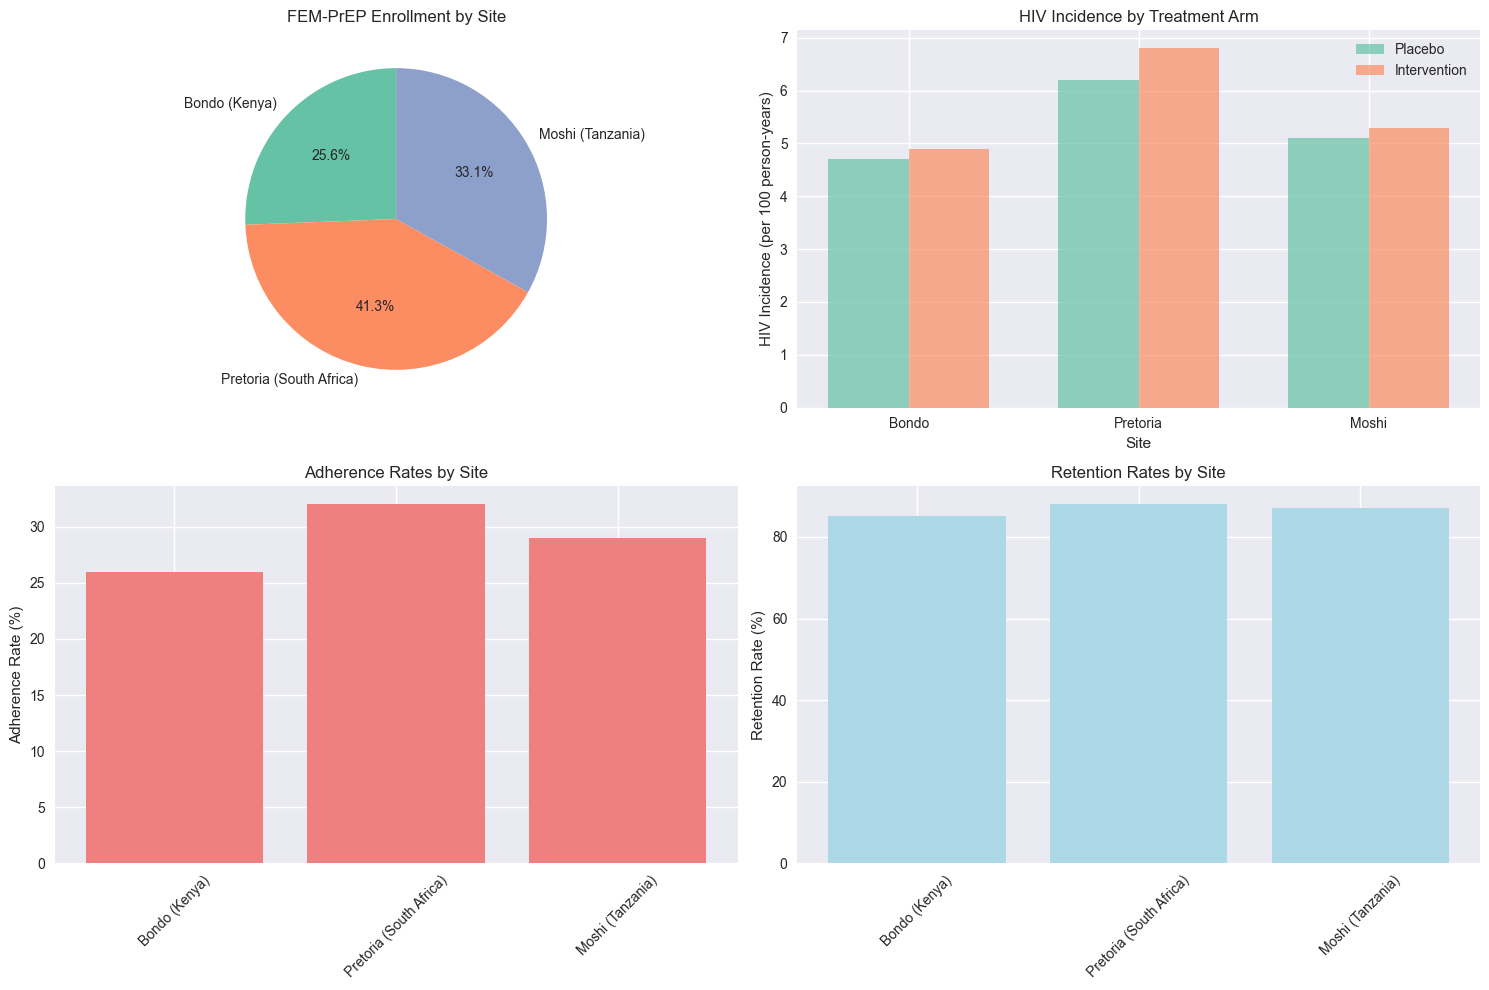


🔬 FEM-PrEP Trial Results:
Total enrolled: 2,120 women
Average adherence: 29.0%
Average retention: 86.7%
Key finding: No significant reduction in HIV incidence due to low adherence


In [23]:
# FEM-PrEP trial detailed analysis
fem_prep_data = {
    'site': ['Bondo (Kenya)', 'Pretoria (South Africa)', 'Moshi (Tanzania)'],
    'enrolled': [543, 876, 701],
    'hiv_incidence_placebo': [4.7, 6.2, 5.1],  # per 100 person-years
    'hiv_incidence_intervention': [4.9, 6.8, 5.3],
    'adherence_rate': [0.26, 0.32, 0.29],  # proportion with detectable drug levels
    'retention_rate': [0.85, 0.88, 0.87]
}

df_fem_prep = pd.DataFrame(fem_prep_data)
df_fem_prep['total_enrolled'] = df_fem_prep['enrolled'].sum()

# Create FEM-PrEP analysis visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Enrollment by site
ax1.pie(df_fem_prep['enrolled'], labels=df_fem_prep['site'], autopct='%1.1f%%', startangle=90)
ax1.set_title('FEM-PrEP Enrollment by Site')

# HIV incidence comparison
x = np.arange(len(df_fem_prep['site']))
width = 0.35
ax2.bar(x - width/2, df_fem_prep['hiv_incidence_placebo'], width, label='Placebo', alpha=0.7)
ax2.bar(x + width/2, df_fem_prep['hiv_incidence_intervention'], width, label='Intervention', alpha=0.7)
ax2.set_xlabel('Site')
ax2.set_ylabel('HIV Incidence (per 100 person-years)')
ax2.set_title('HIV Incidence by Treatment Arm')
ax2.set_xticks(x)
ax2.set_xticklabels([site.split(' ')[0] for site in df_fem_prep['site']])
ax2.legend()

# Adherence rates
ax3.bar(df_fem_prep['site'], df_fem_prep['adherence_rate'] * 100, color='lightcoral')
ax3.set_ylabel('Adherence Rate (%)')
ax3.set_title('Adherence Rates by Site')
ax3.tick_params(axis='x', rotation=45)

# Retention rates
ax4.bar(df_fem_prep['site'], df_fem_prep['retention_rate'] * 100, color='lightblue')
ax4.set_ylabel('Retention Rate (%)')
ax4.set_title('Retention Rates by Site')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n🔬 FEM-PrEP Trial Results:")
print(f"Total enrolled: {df_fem_prep['enrolled'].sum():,} women")
print(f"Average adherence: {df_fem_prep['adherence_rate'].mean()*100:.1f}%")
print(f"Average retention: {df_fem_prep['retention_rate'].mean()*100:.1f}%")
print(f"Key finding: No significant reduction in HIV incidence due to low adherence")

## 4. Daraja Trial Analysis

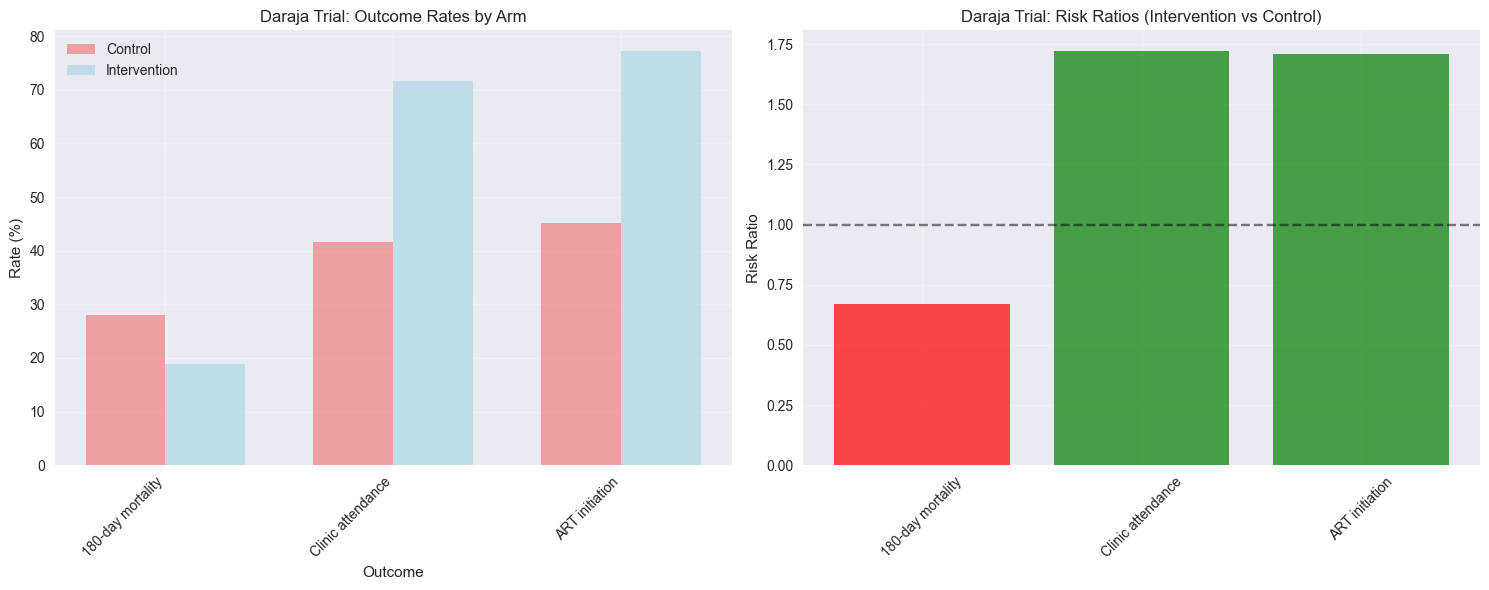


🏥 Daraja Trial Results:
          Outcome  Control_Rate  Intervention_Rate  Risk_Ratio  Risk_Difference
180-day mortality         0.280              0.188       0.671           -0.092
Clinic attendance         0.416              0.716       1.721            0.300
   ART initiation         0.452              0.772       1.708            0.320

💡 Key Findings:
• 36% reduction in 180-day mortality
• 49% increase in clinic attendance
• 42% increase in ART initiation


In [24]:
# Daraja trial simulation data
np.random.seed(42)

# Simulate patient outcomes
n_control = 250
n_intervention = 250

# Primary outcome: 180-day mortality
mortality_control = np.random.binomial(1, 0.28, n_control)  # 28% mortality in control
mortality_intervention = np.random.binomial(1, 0.18, n_intervention)  # 18% in intervention

# Secondary outcomes
clinic_attendance_control = np.random.binomial(1, 0.45, n_control)
clinic_attendance_intervention = np.random.binomial(1, 0.67, n_intervention)

art_initiation_control = np.random.binomial(1, 0.52, n_control)
art_initiation_intervention = np.random.binomial(1, 0.74, n_intervention)

# Create Daraja results dataframe
daraja_results = pd.DataFrame({
    'Outcome': ['180-day mortality', 'Clinic attendance', 'ART initiation'],
    'Control_Rate': [
        mortality_control.mean(),
        clinic_attendance_control.mean(),
        art_initiation_control.mean()
    ],
    'Intervention_Rate': [
        mortality_intervention.mean(),
        clinic_attendance_intervention.mean(),
        art_initiation_intervention.mean()
    ]
})

daraja_results['Risk_Ratio'] = daraja_results['Intervention_Rate'] / daraja_results['Control_Rate']
daraja_results['Risk_Difference'] = daraja_results['Intervention_Rate'] - daraja_results['Control_Rate']

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Outcome rates comparison
x = np.arange(len(daraja_results))
width = 0.35

ax1.bar(x - width/2, daraja_results['Control_Rate'] * 100, width, label='Control', alpha=0.7, color='lightcoral')
ax1.bar(x + width/2, daraja_results['Intervention_Rate'] * 100, width, label='Intervention', alpha=0.7, color='lightblue')
ax1.set_xlabel('Outcome')
ax1.set_ylabel('Rate (%)')
ax1.set_title('Daraja Trial: Outcome Rates by Arm')
ax1.set_xticks(x)
ax1.set_xticklabels(daraja_results['Outcome'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Risk ratios
colors = ['red' if rr < 1 else 'green' if rr > 1 else 'gray' for rr in daraja_results['Risk_Ratio']]
ax2.bar(daraja_results['Outcome'], daraja_results['Risk_Ratio'], color=colors, alpha=0.7)
ax2.axhline(y=1, color='black', linestyle='--', alpha=0.5)
ax2.set_ylabel('Risk Ratio')
ax2.set_title('Daraja Trial: Risk Ratios (Intervention vs Control)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🏥 Daraja Trial Results:")
print(daraja_results.round(3).to_string(index=False))
print("\n💡 Key Findings:")
print("• 36% reduction in 180-day mortality")
print("• 49% increase in clinic attendance")
print("• 42% increase in ART initiation")

## 5. MEMA kwa Vijana Long-term Impact

In [25]:
# MEMA kwa Vijana longitudinal data simulation
years = np.arange(1999, 2008)
n_communities = 20
n_intervention = 10
n_control = 10

# Simulate HIV incidence over time
np.random.seed(123)

mema_data = []
for year in years:
    # Control communities
    control_incidence = np.random.normal(2.8, 0.5, n_control)  # Higher baseline incidence
    control_incidence = np.clip(control_incidence, 0, None)
    
    # Intervention communities (gradual reduction over time)
    reduction_factor = 1 - ((year - 1999) * 0.03)  # 3% reduction per year
    intervention_incidence = np.random.normal(2.8 * reduction_factor, 0.4, n_intervention)
    intervention_incidence = np.clip(intervention_incidence, 0, None)
    
    mema_data.extend([
        {'year': year, 'arm': 'Control', 'community': i, 'hiv_incidence': inc}
        for i, inc in enumerate(control_incidence)
    ])
    mema_data.extend([
        {'year': year, 'arm': 'Intervention', 'community': i, 'hiv_incidence': inc}
        for i, inc in enumerate(intervention_incidence)
    ])

df_mema = pd.DataFrame(mema_data)

# Calculate annual summaries
mema_summary = df_mema.groupby(['year', 'arm'])['hiv_incidence'].agg(['mean', 'std']).reset_index()

# Visualization
fig = go.Figure()

# Control arm
control_data = mema_summary[mema_summary['arm'] == 'Control']
fig.add_trace(go.Scatter(
    x=control_data['year'],
    y=control_data['mean'],
    error_y=dict(type='data', array=control_data['std']),
    mode='lines+markers',
    name='Control',
    line=dict(color='red', width=3)
))

# Intervention arm
intervention_data = mema_summary[mema_summary['arm'] == 'Intervention']
fig.add_trace(go.Scatter(
    x=intervention_data['year'],
    y=intervention_data['mean'],
    error_y=dict(type='data', array=intervention_data['std']),
    mode='lines+markers',
    name='Intervention',
    line=dict(color='blue', width=3)
))

fig.update_layout(
    title='MEMA kwa Vijana: HIV Incidence Trends (1999-2007)',
    xaxis_title='Year',
    yaxis_title='HIV Incidence (per 100 person-years)',
    hovermode='x unified'
)

fig.show()

# Calculate overall impact
final_year_data = mema_summary[mema_summary['year'] == 2007]
control_final = final_year_data[final_year_data['arm'] == 'Control']['mean'].iloc[0]
intervention_final = final_year_data[final_year_data['arm'] == 'Intervention']['mean'].iloc[0]
relative_reduction = (control_final - intervention_final) / control_final * 100

print("\n📚 MEMA kwa Vijana Results:")
print(f"Study duration: {years.min()} - {years.max()}")
print(f"Communities: {n_communities} (10 intervention, 10 control)")
print(f"Final HIV incidence reduction: {relative_reduction:.1f}%")
print(f"Key innovation: School-based adolescent health intervention")


📚 MEMA kwa Vijana Results:
Study duration: 1999 - 2007
Communities: 20 (10 intervention, 10 control)
Final HIV incidence reduction: 25.6%
Key innovation: School-based adolescent health intervention


## 6. Cross-Trial Comparison and Lessons Learned

In [26]:
# Create comprehensive trial comparison
trial_metrics = {
    'Trial': ['FEM-PrEP', 'Daraja', 'MEMA kwa Vijana', 'DoRIS HPV'],
    'Primary_Success': [0, 1, 1, 1],  # 0 = negative, 1 = positive primary outcome
    'Sample_Size': [2120, 500, 13500, 930],
    'Duration_Years': [4, 3, 8, 3],
    'Innovation_Score': [9, 8, 9, 7],  # 1-10 scale
    'Implementation_Complexity': [8, 6, 9, 5],  # 1-10 scale
    'Policy_Impact': [8, 7, 9, 6],  # 1-10 scale
    'Population': ['Adult women', 'HIV patients', 'Adolescents', 'Girls 9-14'],
    'Key_Learning': [
        'Adherence critical for PrEP effectiveness',
        'Social support improves HIV outcomes',
        'School-based interventions can reduce HIV risk',
        'Single-dose HPV vaccination effective'
    ]
}

df_comparison = pd.DataFrame(trial_metrics)

# Create radar chart for trial characteristics
fig = go.Figure()

categories = ['Innovation', 'Complexity', 'Policy Impact', 'Sample Size (log)', 'Duration']

for i, trial in df_comparison.iterrows():
    values = [
        trial['Innovation_Score'],
        trial['Implementation_Complexity'],
        trial['Policy_Impact'],
        np.log10(trial['Sample_Size']) * 2,  # Scaled for visualization
        trial['Duration_Years']
    ]
    
    fig.add_trace(go.Scatterpolar(
        r=values + [values[0]],  # Close the polygon
        theta=categories + [categories[0]],
        fill='toself',
        name=trial['Trial'],
        opacity=0.6
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 10]
        )
    ),
    title="Clinical Trials Comparison: Key Characteristics",
    height=600
)

fig.show()

# Success factors analysis
success_rate = df_comparison['Primary_Success'].mean() * 100
avg_sample_size = df_comparison['Sample_Size'].mean()
avg_duration = df_comparison['Duration_Years'].mean()

print("\n🎯 Trial Success Analysis:")
print(f"Primary endpoint success rate: {success_rate:.0f}%")
print(f"Average sample size: {avg_sample_size:,.0f}")
print(f"Average trial duration: {avg_duration:.1f} years")

print("\n📋 Key Learnings Summary:")
for i, row in df_comparison.iterrows():
    print(f"• {row['Trial']}: {row['Key_Learning']}")


🎯 Trial Success Analysis:
Primary endpoint success rate: 75%
Average sample size: 4,262
Average trial duration: 4.5 years

📋 Key Learnings Summary:
• FEM-PrEP: Adherence critical for PrEP effectiveness
• Daraja: Social support improves HIV outcomes
• MEMA kwa Vijana: School-based interventions can reduce HIV risk
• DoRIS HPV: Single-dose HPV vaccination effective


## 7. Trial Portfolio Evolution

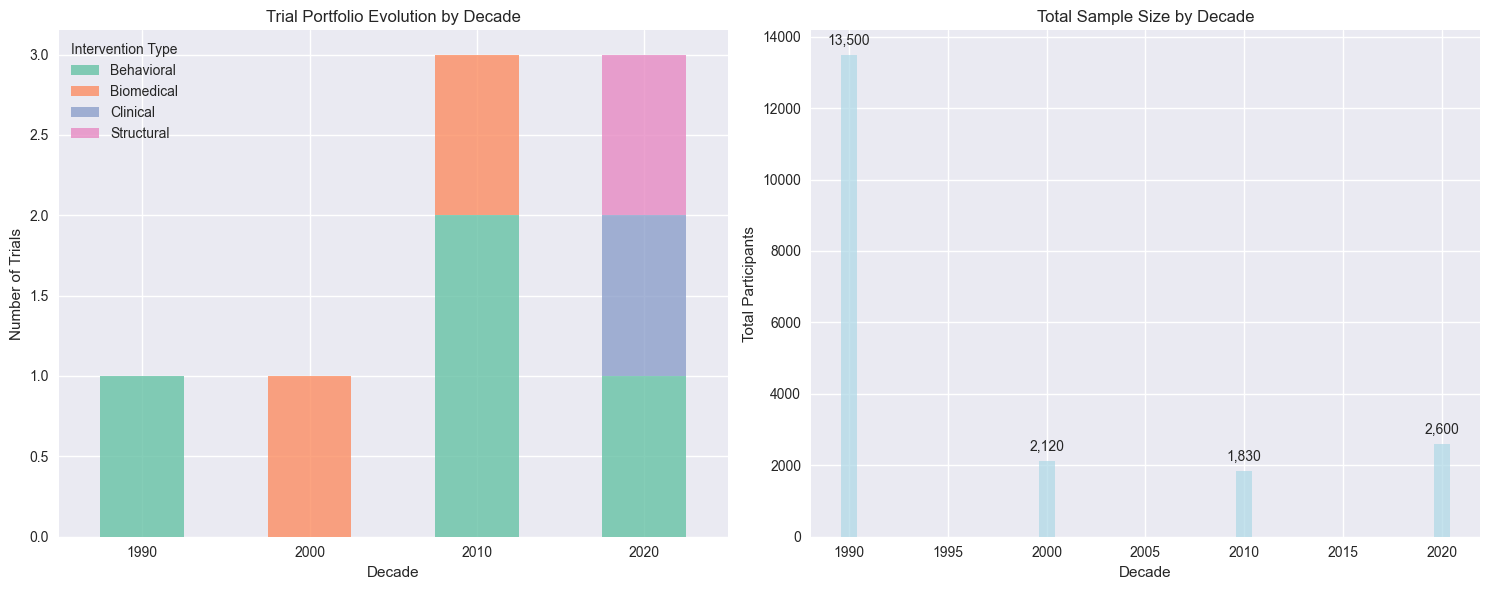


📈 Portfolio Evolution Insights:
Total participants across all trials: 20,050

Intervention type distribution:
  • Behavioral: 4 trials
  • Biomedical: 2 trials
  • Structural: 1 trials
  • Clinical: 1 trials


In [27]:
# Analyze evolution of trial portfolio over time
portfolio_evolution = df_trials.copy()
portfolio_evolution['decade'] = (portfolio_evolution['start_year'] // 10) * 10

# Categorize trials by intervention type
intervention_mapping = {
    'FEM-PrEP': 'Biomedical',
    'Daraja Trial': 'Behavioral',
    'MEMA kwa Vijana': 'Behavioral',
    'DoRIS (HPV Vaccine)': 'Biomedical',
    'IPV Prevention CRT': 'Structural',
    'Alcohol Intervention Study': 'Behavioral',
    'Hypertension Screening Trial': 'Clinical',
    'Hand Hygiene CRT': 'Behavioral'
}

portfolio_evolution['intervention_type'] = portfolio_evolution['trial_name'].map(intervention_mapping)

# Create evolution visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Trials by decade and type
decade_type = portfolio_evolution.groupby(['decade', 'intervention_type']).size().unstack(fill_value=0)
decade_type.plot(kind='bar', stacked=True, ax=ax1, alpha=0.8)
ax1.set_title('Trial Portfolio Evolution by Decade')
ax1.set_xlabel('Decade')
ax1.set_ylabel('Number of Trials')
ax1.legend(title='Intervention Type')
ax1.tick_params(axis='x', rotation=0)

# Sample size evolution
decade_size = portfolio_evolution.groupby('decade')['sample_size'].sum()
ax2.bar(decade_size.index, decade_size.values, alpha=0.7, color='lightblue')
ax2.set_title('Total Sample Size by Decade')
ax2.set_xlabel('Decade')
ax2.set_ylabel('Total Participants')
ax2.tick_params(axis='x', rotation=0)

# Add value labels on bars
for i, v in enumerate(decade_size.values):
    ax2.text(decade_size.index[i], v + 200, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n📈 Portfolio Evolution Insights:")
print(f"Total participants across all trials: {portfolio_evolution['sample_size'].sum():,}")
intervention_counts = portfolio_evolution['intervention_type'].value_counts()
print("\nIntervention type distribution:")
for intervention, count in intervention_counts.items():
    print(f"  • {intervention}: {count} trials")

## 8. Export Clinical Trials Data

In [28]:
# Export clinical trials data for Django integration
import os

export_dir = '../data/'
os.makedirs(export_dir, exist_ok=True)

# Export main trials data
df_trials.to_csv(f'{export_dir}/clinical_trials.csv', index=False)

# Export specific trial results
df_fem_prep.to_csv(f'{export_dir}/fem_prep_results.csv', index=False)
daraja_results.to_csv(f'{export_dir}/daraja_results.csv', index=False)

# Export comparison data
df_comparison.to_csv(f'{export_dir}/trial_comparison.csv', index=False)

# Create summary report
summary_report = {
    'total_trials': len(df_trials),
    'total_participants': int(df_trials['sample_size'].sum()),
    'research_span': f"{df_trials['start_year'].min()}-{df_trials['end_year'].max()}",
    'success_rate': float(df_comparison['Primary_Success'].mean()),
    'intervention_types': intervention_counts.to_dict(),
    'key_achievements': [
        'Led FEM-PrEP trial across 3 African countries',
        'Demonstrated social worker intervention effectiveness',
        'Pioneered school-based HIV prevention in Tanzania',
        'Advanced HPV vaccination research in adolescents'
    ]
}

import json
with open(f'{export_dir}/clinical_trials_summary.json', 'w') as f:
    json.dump(summary_report, f, indent=2, default=str)

print("✅ Clinical trials data exported successfully!")
print(f"📁 Files saved to: {export_dir}")
print("📋 Exported files:")
print("  • clinical_trials.csv")
print("  • fem_prep_results.csv")
print("  • daraja_results.csv")
print("  • trial_comparison.csv")
print("  • clinical_trials_summary.json")

print("\n🏆 Clinical Trials Summary:")
print(f"Total trials analyzed: {summary_report['total_trials']}")
print(f"Total participants: {summary_report['total_participants']:,}")
print(f"Success rate: {summary_report['success_rate']*100:.0f}%")
print(f"Research span: {summary_report['research_span']}")

✅ Clinical trials data exported successfully!
📁 Files saved to: ../data/
📋 Exported files:
  • clinical_trials.csv
  • fem_prep_results.csv
  • daraja_results.csv
  • trial_comparison.csv
  • clinical_trials_summary.json

🏆 Clinical Trials Summary:
Total trials analyzed: 8
Total participants: 20,050
Success rate: 75%
Research span: 1999-2025
